# Data Cleaning

## Importing Libraries and Loading the Data

In [1]:
import pandas as pd

# Reads the raw transaction CSV file into a pandas DataFrame object named 'df'
df = pd.read_csv("Retail_Transactions_Dataset.csv")

## Initial Data Inspection

In [2]:
# Displays the first 5 rows of the DataFrame to inspect columns and sample data values

df.head()

,Transaction_ID,Date,Customer_Name,Product,Total_Items,Total_Cost,Payment_Method,City,Store_Type,Discount_Applied,Customer_Category,Season,Promotion
0,1000000000,2022-01-21 06:27:29,Stacey Price,"['Ketchup', 'Shaving Cream', 'Light Bulbs']",3,71.65,Mobile Payment,Los Angeles,Warehouse Club,True,Homemaker,Winter,NaN
1,1000000001,2023-03-01 13:01:21,Michelle Carlson,"['Ice Cream', 'Milk', 'Olive Oil', 'Bread', 'P...",2,25.93,Cash,San Francisco,Specialty Store,True,Professional,Fall,BOGO (Buy One Get One)
2,1000000002,2024-03-21 15:37:04,Lisa Graves,['Spinach'],6,41.49,Credit Card,Houston,Department Store,True,Professional,Winter,NaN
3,1000000003,2020-10-31 09:59:47,Mrs. Patricia May,"['Tissues', 'Mustard']",1,39.34,Mobile Payment,Chicago,Pharmacy,True,Homemaker,Spring,NaN
4,1000000004,2020-12-10 00:59:59,Susan Mitchell,['Dish Soap'],10,16.42,Debit Card,Houston,Specialty Store,False,Young Adult,Winter,Discount on Selected Items


## Checking Data Types 

In [ ]:
# Prints a concise summary of the DataFrame structure, including column data types,
# total non-null values, and overall memory usage

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Transaction_ID     1000000 non-null  int64  
 1   Date               1000000 non-null  str    
 2   Customer_Name      1000000 non-null  str    
 3   Product            1000000 non-null  str    
 4   Total_Items        1000000 non-null  int64  
 5   Total_Cost         1000000 non-null  float64
 6   Payment_Method     1000000 non-null  str    
 7   City               1000000 non-null  str    
 8   Store_Type         1000000 non-null  str    
 9   Discount_Applied   1000000 non-null  bool   
 10  Customer_Category  1000000 non-null  str    
 11  Season             1000000 non-null  str    
 12  Promotion          666057 non-null   str    
dtypes: bool(1), float64(1), int64(2), str(9)
memory usage: 92.5 MB


## Summary Statistics of Numerical Data

In [ ]:
# Generates descriptive statistics (mean, min, max, standard deviation, quartiles) 
# for all numerical columns in the dataset and rounds it off

df.describe().round()

,Transaction_ID,Total_Items,Total_Cost
count,1.000000e+06,1000000.0,1000000.0
mean,1.000500e+09,5.0,52.0
std,2.886750e+05,3.0,27.0
min,1.000000e+09,1.0,5.0
25%,1.000250e+09,3.0,29.0
50%,1.000500e+09,5.0,52.0
75%,1.000750e+09,8.0,76.0
max,1.001000e+09,10.0,100.0


## Checking Dataset Dimensions

In [5]:
# Returns a tuple representing the dimensionality of the DataFrame: (rows, columns)
df.shape

(1000000, 13)

## Identifying Missing Values

In [6]:
# Calculates the absolute count of missing (NaN) entries across every column
df.isnull().sum()

Transaction_ID            0
Date                      0
Customer_Name             0
Product                   0
Total_Items               0
Total_Cost                0
Payment_Method            0
City                      0
Store_Type                0
Discount_Applied          0
Customer_Category         0
Season                    0
Promotion            333943
dtype: int64

In [7]:
# Divides the missing value counts by the dataset length to find the percentage 
# of missing data per column
df.isnull().sum()/len(df)*100

Transaction_ID        0.0000
Date                  0.0000
Customer_Name         0.0000
Product               0.0000
Total_Items           0.0000
Total_Cost            0.0000
Payment_Method        0.0000
City                  0.0000
Store_Type            0.0000
Discount_Applied      0.0000
Customer_Category     0.0000
Season                0.0000
Promotion            33.3943
dtype: float64

## Checking Duplicate Values

In [8]:
# Number of rows that are duplicate and the number of columns.
df[df.duplicated()].shape

(0, 13)

## Primary Key Validation

In [9]:
# Checks the frequency of the individual transaction IDs to see if they repeat
df['Transaction_ID'].value_counts()

Transaction_ID
1000000000    1
1000000001    1
1000000002    1
1000000003    1
1000000004    1
             ..
1000999995    1
1000999996    1
1000999997    1
1000999998    1
1000999999    1
Name: count, Length: 1000000, dtype: int64

In [ ]:
# Checks the frequency of the first 5 individual transaction IDs to see if they repeat (done for better understanding)
df['Transaction_ID'].value_counts().head(5)

Transaction_ID
1000000000    1
1000000001    1
1000000002    1
1000000003    1
1000000004    1
Name: count, dtype: int64

In [ ]:
# Categorical Column Explorer: Loops through all columns and prints the frequency distribution of values 
# for any column that has fewer than 20 unique categories
def explore_categorical_columns(df,threshold = 20):
    for col in df.columns:
        if df[col].nunique(dropna = False)< threshold:
            print(f"\ncolumn:{col}")
            print(df[col].value_counts(dropna = False))
            print("_"*50)

In [12]:
explore_categorical_columns(df)


column:Total_Items
Total_Items
2     100444
5     100284
1     100097
6     100039
7     100027
8     100004
4      99962
3      99806
10     99782
9      99555
Name: count, dtype: int64
__________________________________________________

column:Payment_Method
Payment_Method
Cash              250230
Debit Card        250074
Credit Card       249985
Mobile Payment    249711
Name: count, dtype: int64
__________________________________________________

column:City
City
Boston           100566
Dallas           100559
Seattle          100167
Chicago          100059
Houston          100050
New York         100007
Los Angeles       99879
Miami             99839
San Francisco     99808
Atlanta           99066
Name: count, dtype: int64
__________________________________________________

column:Store_Type
Store_Type
Supermarket          166936
Pharmacy             166915
Convenience Store    166749
Warehouse Club       166685
Department Store     166614
Specialty Store      166101
Name: count, 

## Handling Missing Values 

In [13]:
# Extracts the most common value (mode) from the 'Promotion' column
mode_value = df['Promotion'].mode()[0]
mode_value

'Discount on Selected Items'

In [14]:
# Fills the empty spaces (NaN) in the 'Promotion' column with that mode value
df['Promotion'] = df['Promotion'].fillna(mode_value)

In [15]:
# Re-runs the null check to ensure that the imputation step worked
df.isnull().sum()

Transaction_ID       0
Date                 0
Customer_Name        0
Product              0
Total_Items          0
Total_Cost           0
Payment_Method       0
City                 0
Store_Type           0
Discount_Applied     0
Customer_Category    0
Season               0
Promotion            0
dtype: int64

## Correcting data types

In [16]:
# Converts the 'Date' column from a generic string/object to a standardized datetime data type
df['Date'] = pd.to_datetime(df['Date'])

In [17]:
# Checks data types again to confirm the datetime transformation
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 13 columns):
 #   Column             Non-Null Count    Dtype         
---  ------             --------------    -----         
 0   Transaction_ID     1000000 non-null  int64         
 1   Date               1000000 non-null  datetime64[us]
 2   Customer_Name      1000000 non-null  str           
 3   Product            1000000 non-null  str           
 4   Total_Items        1000000 non-null  int64         
 5   Total_Cost         1000000 non-null  float64       
 6   Payment_Method     1000000 non-null  str           
 7   City               1000000 non-null  str           
 8   Store_Type         1000000 non-null  str           
 9   Discount_Applied   1000000 non-null  bool          
 10  Customer_Category  1000000 non-null  str           
 11  Season             1000000 non-null  str           
 12  Promotion          1000000 non-null  str           
dtypes: bool(1), datetime64[us](1), float64(

In [ ]:
# It replaces remaining null promotions with the string 'None'(Custom Label)
df['Promotion'] = df['Promotion'].fillna('None')

In [19]:
print(df['Promotion'])

0         Discount on Selected Items
1             BOGO (Buy One Get One)
2         Discount on Selected Items
3         Discount on Selected Items
4         Discount on Selected Items
                     ...            
999995    Discount on Selected Items
999996    Discount on Selected Items
999997    Discount on Selected Items
999998        BOGO (Buy One Get One)
999999    Discount on Selected Items
Name: Promotion, Length: 1000000, dtype: str


## Outliers detection(visually)

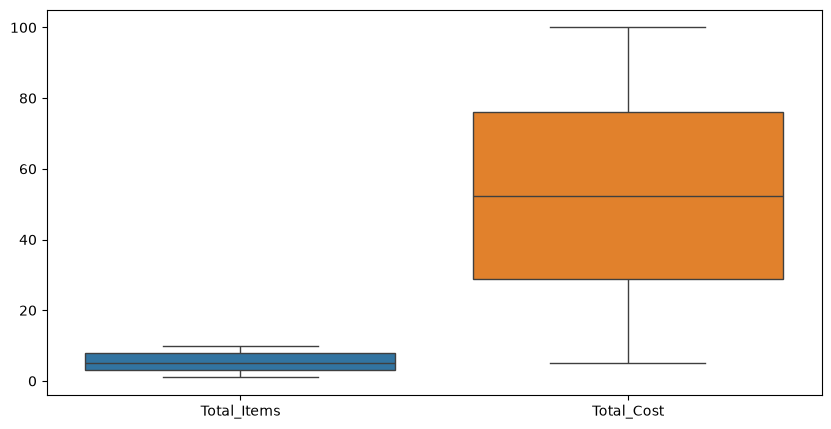

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['Total_Items', 'Total_Cost']

plt.figure(figsize=(10,5))

sns.boxplot(data=df[cols])

plt.show()

## Outlier detection using IQR

In [21]:
Q1 = df['Total_Items'].quantile(0.25)
Q3 = df['Total_Items'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['Total_Items'] < lower_bound) |
    (df['Total_Items'] > upper_bound)
]

print(outliers)

Empty DataFrame
Columns: [Transaction_ID, Date, Customer_Name, Product, Total_Items, Total_Cost, Payment_Method, City, Store_Type, Discount_Applied, Customer_Category, Season, Promotion]
Index: []


In [ ]:
## Outliers and total number of columns.

In [22]:
print(outliers.shape)

(0, 13)


# Exploratory Data Analysis (EDA)

## Univariate Analysis

In [23]:
# Summary statistics for numerical column

numeric_cols=['Total_Items','Total_Cost','Discount_Applied']
summary = df[numeric_cols].describe().T
summary['median'] = df[numeric_cols].median()
summary['IQR'] = summary['75%']-summary['25%']
summary['skewness'] = df[numeric_cols].skew()
print("Numeric Summary Statistics : \n")
summary

Numeric Summary Statistics : 



,count,mean,std,min,25%,50%,75%,max,median,IQR,skewness
Total_Items,1000000.0,5.495941,2.871654,1.0,3.00,5.00,8.00,10.0,5.00,5.00,0.001557
Total_Cost,1000000.0,52.455220,27.416989,5.0,28.71,52.42,76.19,100.0,52.42,47.48,0.001571


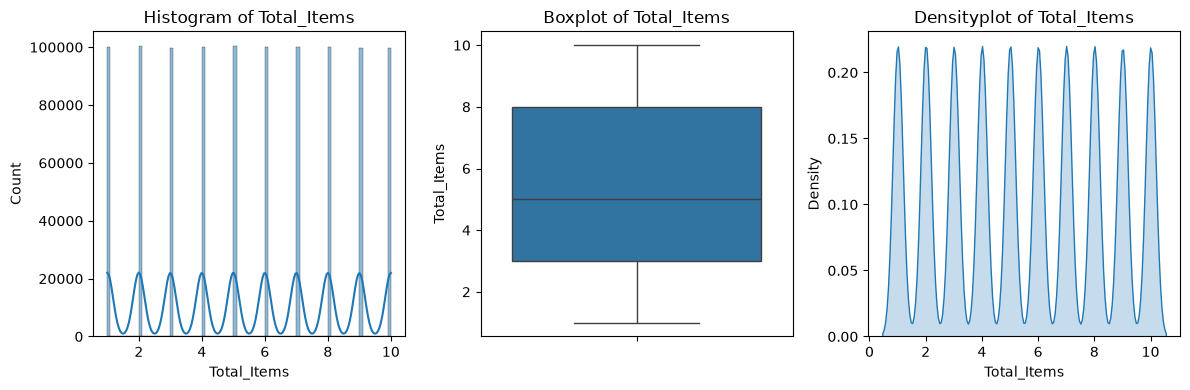

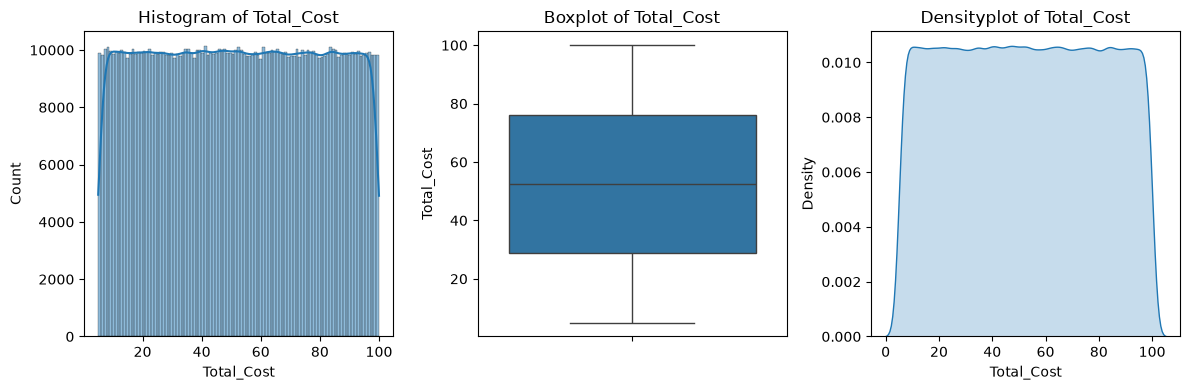

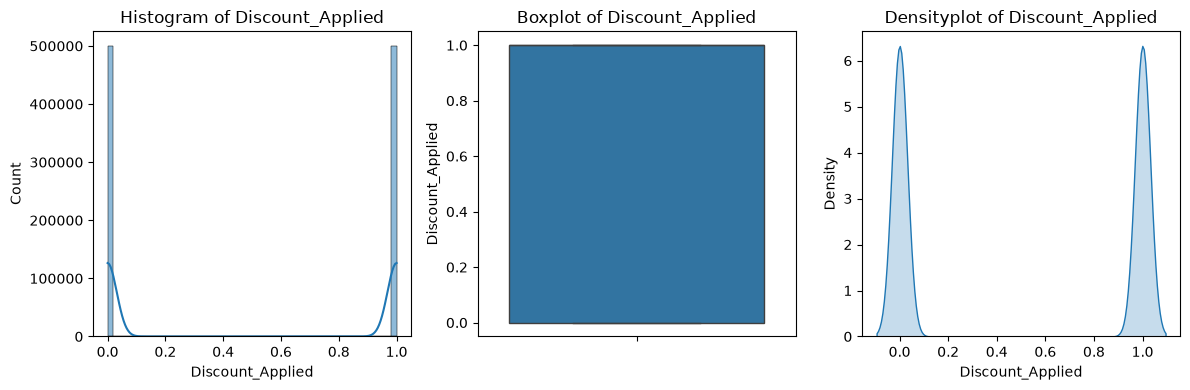

In [24]:
# Histogram,Boxplot,Density plot for numerical columns
for col in numeric_cols:
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    sns.histplot(df[col],kde=True)
    plt.title(f'Histogram of {col}')

    plt.subplot(1,3,2)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')

    plt.subplot(1,3,3)
    sns.kdeplot(df[col], fill=True)
    plt.title(f'Densityplot of {col}')

    plt.tight_layout()
    plt.show()


In [25]:
# Date/time variables
date_cols = ['Date']
for col in date_cols:
    print(f"\n Date range for {col}: {df[col].min()} to {df[col].max()}")
    print(f"time span: {(df[col].max()-df[col].min()).days}days")

    


 Date range for Date: 2020-01-01 00:03:54 to 2024-05-18 19:31:03
time span: 1599days


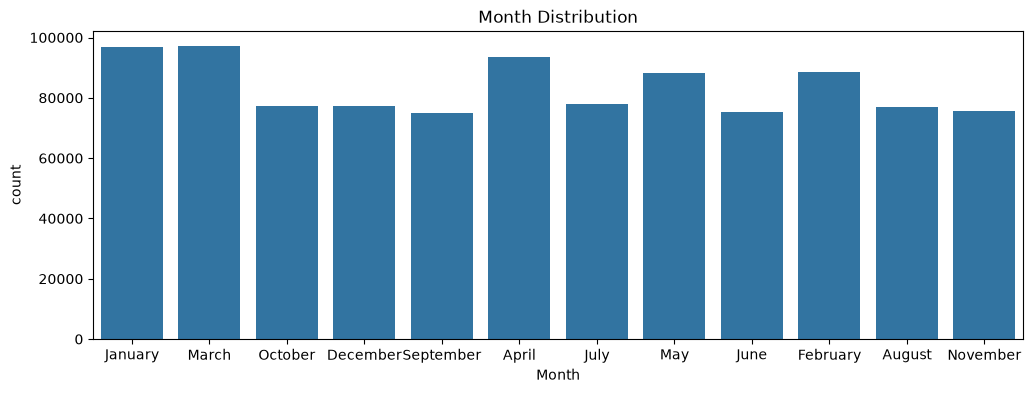

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.month_name()

plt.figure(figsize=(12,4))
sns.countplot(x='Month', data=df)
plt.title('Month Distribution')
plt.show()

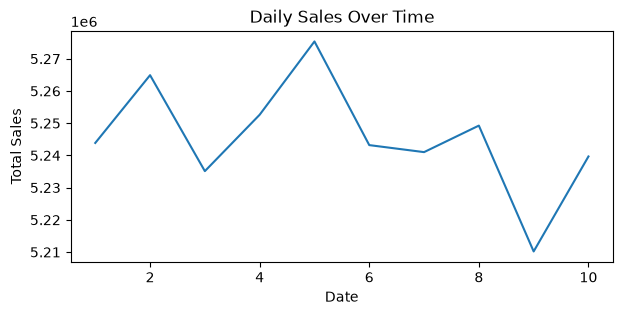

In [27]:
# Group by date and sum the transaction amounts
daily_sales = df.groupby('Total_Items')['Total_Cost'].sum()

plt.figure(figsize=(7, 3))
daily_sales.plot()
plt.title('Daily Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.show()

## Title: Sales, Discounts, Purchases, and Payment Trends

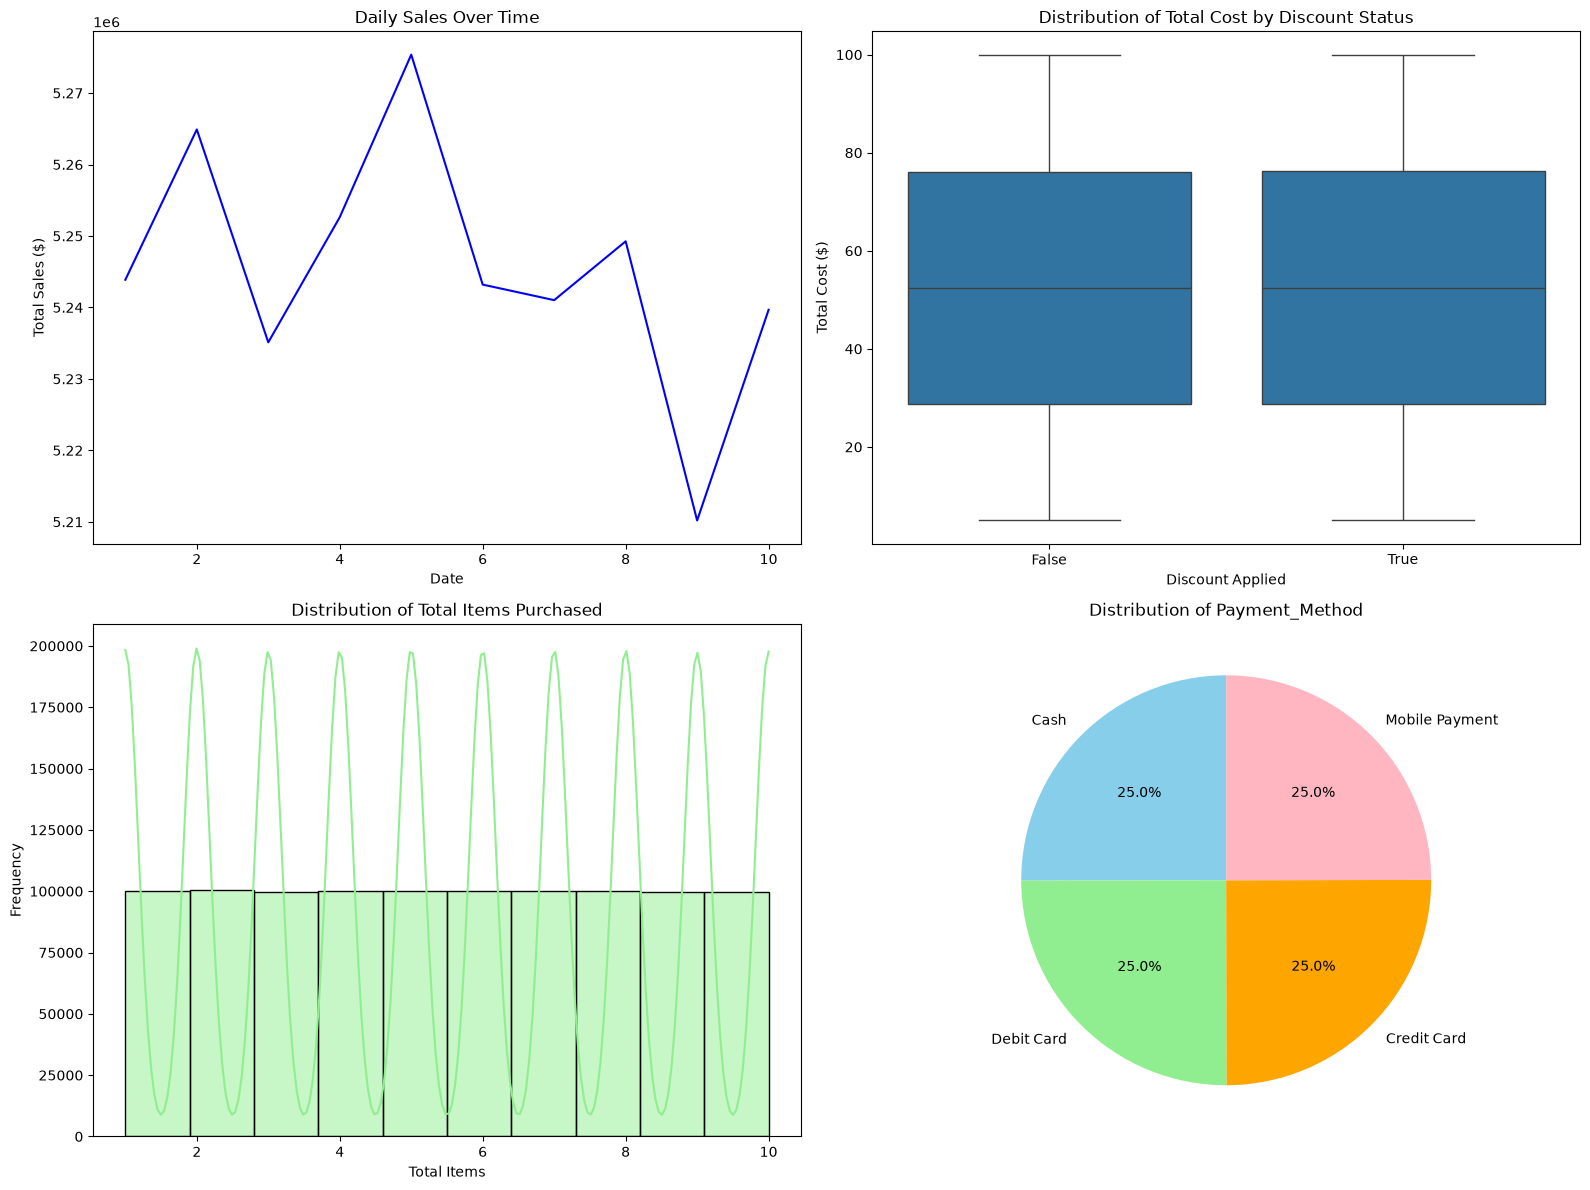

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1: Line Plot (Sales Over Time)
daily_sales.plot(kind='line', color='blue', ax=axes[0, 0])
axes[0, 0].set_title('Daily Sales Over Time')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Total Sales ($)')

# Chart 2: Box Plot (Total Cost by Discount Status)
sns.boxplot(data=df, x='Discount_Applied', y='Total_Cost', ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Total Cost by Discount Status')
axes[0, 1].set_xlabel('Discount Applied')
axes[0, 1].set_ylabel('Total Cost ($)')

# Chart 3: Histogram (Total Items Purchased)
sns.histplot(df['Total_Items'], bins=10, kde=True, color='lightgreen', ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Total Items Purchased')
axes[1, 0].set_xlabel('Total Items')
axes[1, 0].set_ylabel('Frequency')

# Chart 4: Pie Chart (Payment Method Distribution)
Payment_Method = df['Payment_Method'].value_counts()

Payment_Method.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightgreen', 'orange', 'lightpink'], ax=axes[1, 1])
axes[1, 1].set_title('Distribution of Payment_Method')
axes[1, 1].set_ylabel('')

# Adjust layout and display the plots
plt.tight_layout()
plt.show()

## Bivariate Analysis

## Relationship Between Total Items, Cost, and Discounts

Index(['Transaction_ID', 'Date', 'Customer_Name', 'Product', 'Total_Items',
       'Total_Cost', 'Payment_Method', 'City', 'Store_Type',
       'Discount_Applied', 'Customer_Category', 'Season', 'Promotion',
       'Month'],
      dtype='str')


C:\Users\yadav\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


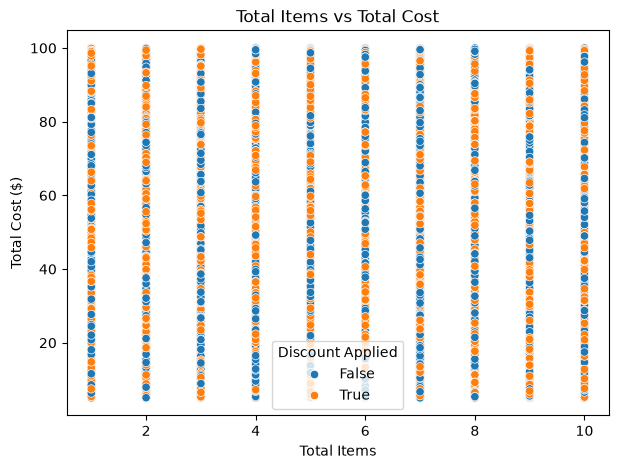

In [29]:
# Check column names
print(df.columns)

# Ensure the columns exist and are numeric
if 'Total_Items' in df.columns and 'Total_Cost' in df.columns and 'Discount_Applied' in df.columns:
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=df, x='Total_Items', y='Total_Cost', hue='Discount_Applied')
    plt.title('Total Items vs Total Cost')
    plt.xlabel('Total Items')
    plt.ylabel('Total Cost ($)')
    plt.legend(title='Discount Applied')
    plt.show()
else:
    print("One or more columns ('Total_Items', 'Total_Cost', 'Discount_Applied') do not exist in the DataFrame.")

## Customer Purchase Frequency Distribution¶
### This code counts the number of transactions per customer category and visualizes the distribution using a histogram to show how frequently customers make purchases.

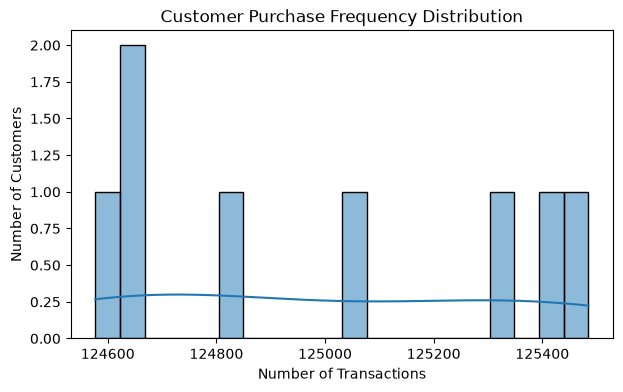

In [30]:
# Group by customer and count the number of transactions
customer_frequency = df.groupby('Customer_Category')['Transaction_ID'].count()

plt.figure(figsize=(7,4))
sns.histplot(customer_frequency, kde=True, bins=20)
plt.title('Customer Purchase Frequency Distribution')
plt.xlabel('Number of Transactions')
plt.ylabel('Number of Customers')
plt.show()

## Impact of Discounts on Average Total Cost

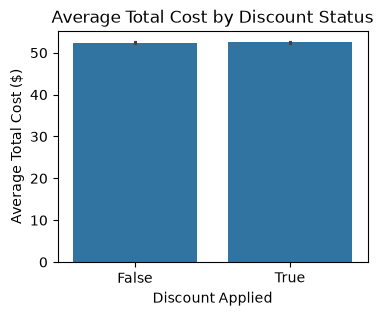

In [31]:
plt.figure(figsize=(4, 3))
sns.barplot(data=df, x='Discount_Applied', y='Total_Cost', estimator='mean')
plt.title('Average Total Cost by Discount Status')
plt.xlabel('Discount Applied')
plt.ylabel('Average Total Cost ($)')
plt.show()

In [35]:
## Final dashboard before creating dashboard.

In [36]:
df.head()

,Transaction_ID,Date,Customer_Name,Product,Total_Items,Total_Cost,Payment_Method,City,Store_Type,Discount_Applied,Customer_Category,Season,Promotion,Month
0,1000000000,2022-01-21 06:27:29,Stacey Price,"['Ketchup', 'Shaving Cream', 'Light Bulbs']",3,71.65,Mobile Payment,Los Angeles,Warehouse Club,True,Homemaker,Winter,Discount on Selected Items,January
1,1000000001,2023-03-01 13:01:21,Michelle Carlson,"['Ice Cream', 'Milk', 'Olive Oil', 'Bread', 'P...",2,25.93,Cash,San Francisco,Specialty Store,True,Professional,Fall,BOGO (Buy One Get One),March
2,1000000002,2024-03-21 15:37:04,Lisa Graves,['Spinach'],6,41.49,Credit Card,Houston,Department Store,True,Professional,Winter,Discount on Selected Items,March
3,1000000003,2020-10-31 09:59:47,Mrs. Patricia May,"['Tissues', 'Mustard']",1,39.34,Mobile Payment,Chicago,Pharmacy,True,Homemaker,Spring,Discount on Selected Items,October
4,1000000004,2020-12-10 00:59:59,Susan Mitchell,['Dish Soap'],10,16.42,Debit Card,Houston,Specialty Store,False,Young Adult,Winter,Discount on Selected Items,December
